# Interpretation of the results

The model pipline has been run for the following combinations:
- assets: tesla, sp500, nastaq, bitcoin
- target: stockprice, volume, volatiliy
- phase 1-4
We take the following results from the model as Inputs:
- The model prediction metrics: val_loss, accuracy, f1-score
- The feature weighting for every run: permutation-analysis for feature importance



### 1. Loading the datasets and merge them

In [ ]:
import pandas as pd

# Daten einlesen
df_without_twitter = pd.read_csv('results_all_scenarios_v3_WITHOUT_TWITTER_DATA.csv')
df_all = pd.read_csv('results_all_scenarios_v3_WITH_TWITTER_DATA.csv')

In [99]:
# Merge auf asset, target und phase und Unterscheidung der Spalten-Namen
df_merged = pd.merge(
    df_all,
    df_without_twitter,
    on=['asset', 'target', 'phase'],
    suffixes=('_all', '_no_twitter')
)

# Differenzen berechnen
for metric in ['accuracy', 'f1_score']:
    df_merged[f'{metric}_diff'] = df_merged[f'{metric}_all'] - df_merged[f'{metric}_no_twitter']

# Ergebnis prüfen
print(df_merged.head())
print(df_merged.info())


   asset             target   phase  val_loss_all  accuracy_all  f1_score_all  \
0  tesla  change_stockprice  phase1      0.620581      0.688172      0.325581   
1  tesla  change_stockprice  phase2      0.584537      0.628000      0.392157   
2  tesla  change_stockprice  phase3      0.612578      0.587413      0.271605   
3  tesla  change_stockprice  phase4      0.668873      0.740000      0.380952   
4  tesla  change_stockprice    full      0.595802      0.513605      0.505190   

   val_loss_no_twitter  accuracy_no_twitter  f1_score_no_twitter  \
0             0.575243             0.661290             0.136986   
1             0.562737             0.672000             0.397059   
2             0.566306             0.692308             0.488372   
3             0.588844             0.740000             0.480000   
4             0.519623             0.634354             0.547368   

   accuracy_diff  f1_score_diff  
0       0.026882       0.188595  
1      -0.044000      -0.004902  
2 

### Plot differences

For every scenario, we look at the difference in accuracy and f1 score of the data with and without twitter data.
Rationale: If the diff is positive, the tweets had a positve impact on the predictability, if they are negative, they dont.

KeyboardInterrupt: 

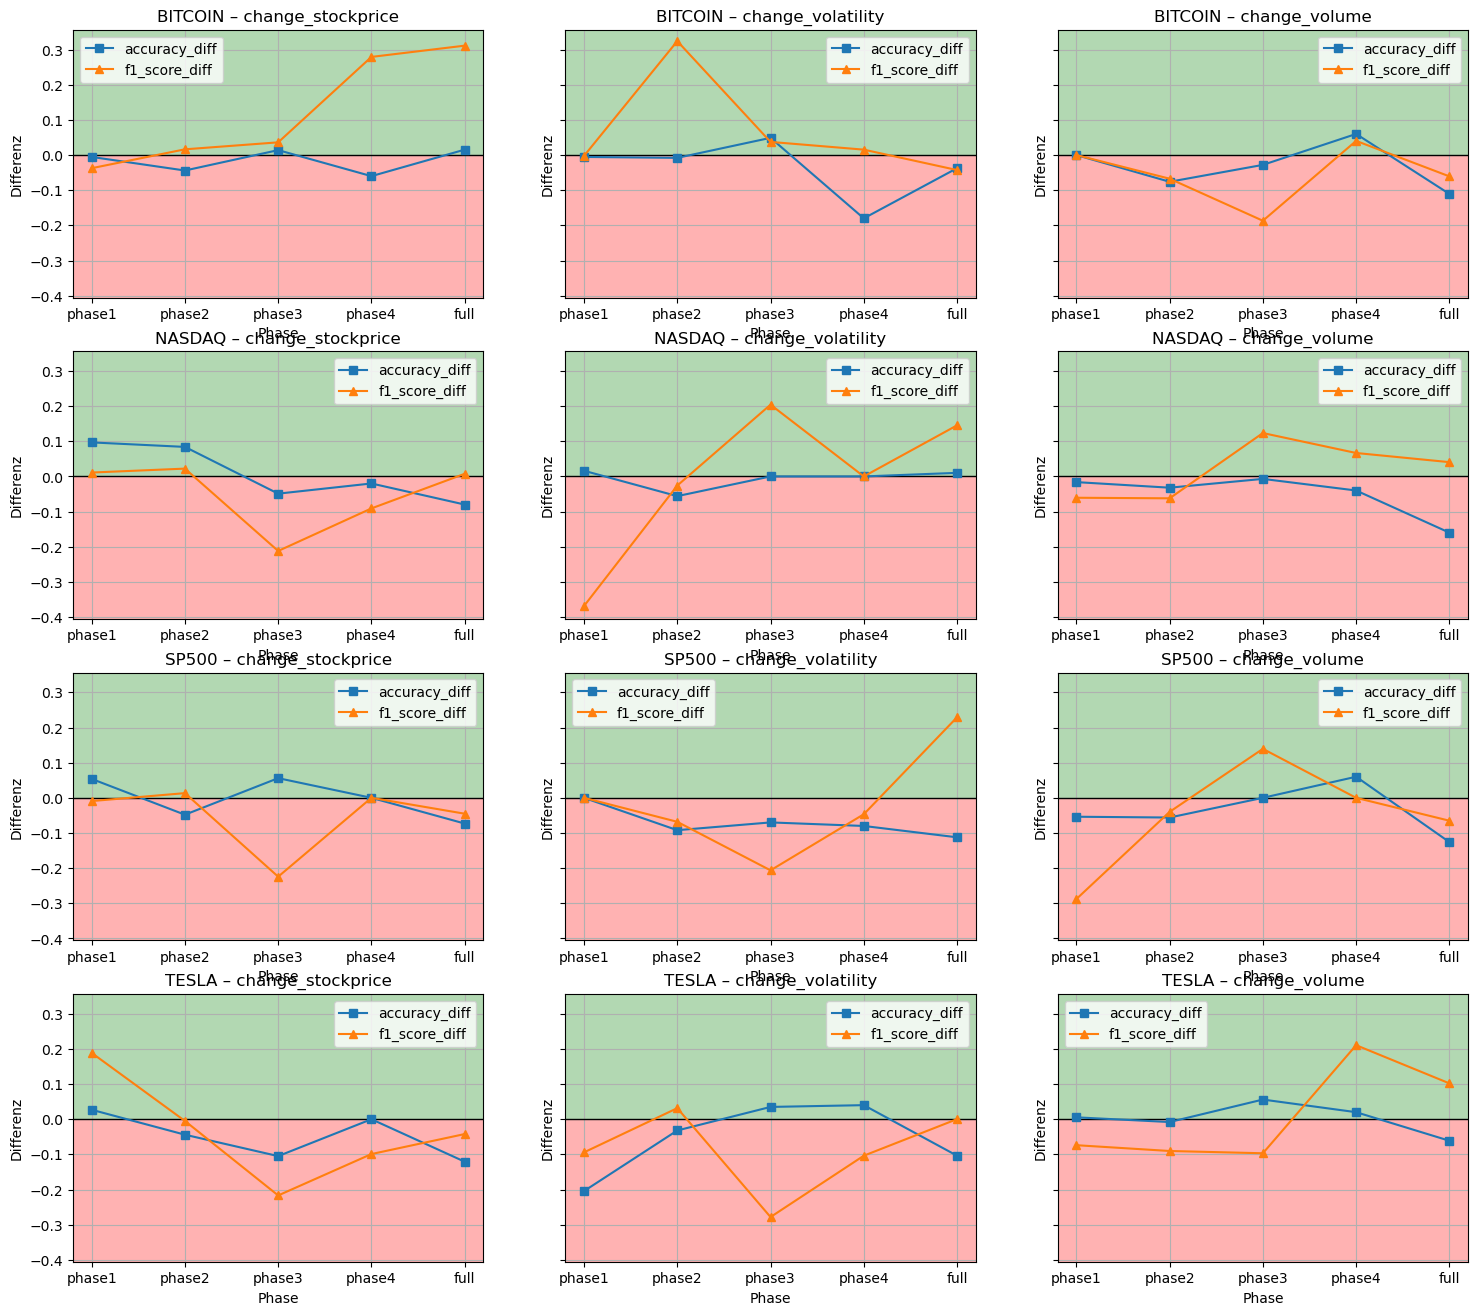

In [107]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# Phasen in der richtigen Reihenfolge
phase_order = ['phase1', 'phase2', 'phase3', 'phase4', 'full']
df_merged['phase'] = pd.Categorical(df_merged['phase'], categories=phase_order, ordered=True)

# Gruppieren
grouped = df_merged.groupby(['asset', 'target'])
combos = list(grouped.groups.keys())
n_plots = len(combos)

# **Globale** y-Grenzen (für konsistente Schattierung und Achsen über alle Subplots)
global_min = df_merged[['accuracy_diff','f1_score_diff']].min().min()
global_max = df_merged[['accuracy_diff','f1_score_diff']].max().max()
ymin = global_min * 1.1
ymax = global_max * 1.1

# Raster: 3 Spalten, automatisch so viele Reihen wie nötig
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4), sharey=True)
axes = axes.flatten()

for ax, (asset, target) in zip(axes, combos):
    grp = grouped.get_group((asset, target)).sort_values('phase')
    
    # negative / positive Bereiche einfärben (global)
    ax.axhspan(ymin,   0,   facecolor='red',   alpha=0.3)
    ax.axhspan(0,      ymax, facecolor='green', alpha=0.3)
    ax.axhline(0, color='black', linewidth=1)
    
    # Linienplots
    ax.plot(grp['phase'], grp['accuracy_diff'], marker='s', label='accuracy_diff')
    ax.plot(grp['phase'], grp['f1_score_diff'], marker='^', label='f1_score_diff')
    
    # Titel und Achsen
    ax.set_title(f'{asset.upper()} – {target}')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Differenz')
    ax.set_ylim(ymin, ymax)
    ax.grid(True)
    ax.legend()

# Unbenutzte Achsen entfernen (falls n_rows*n_cols > n_plots)
for ax in axes[n_plots:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Plot f1 and accuracy over phases

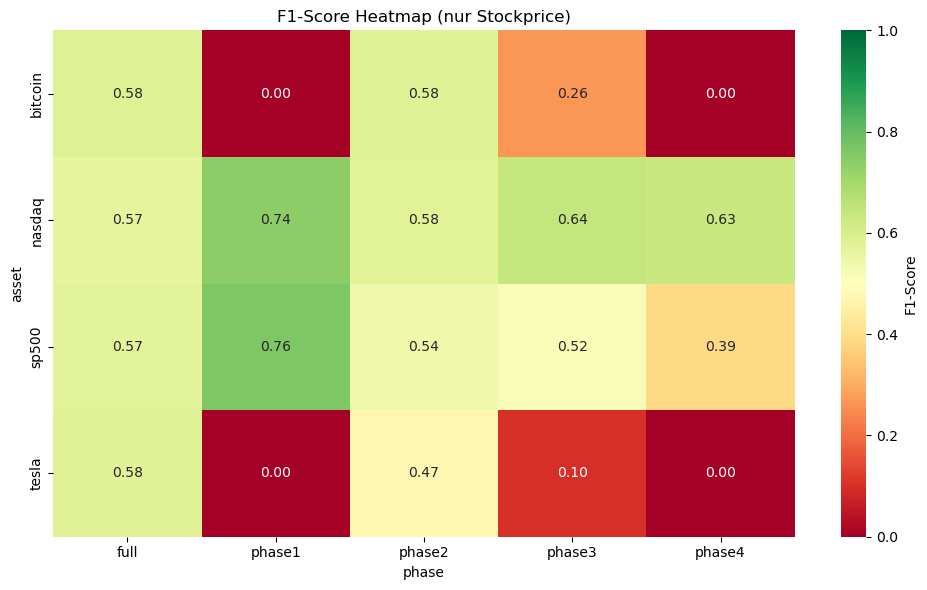

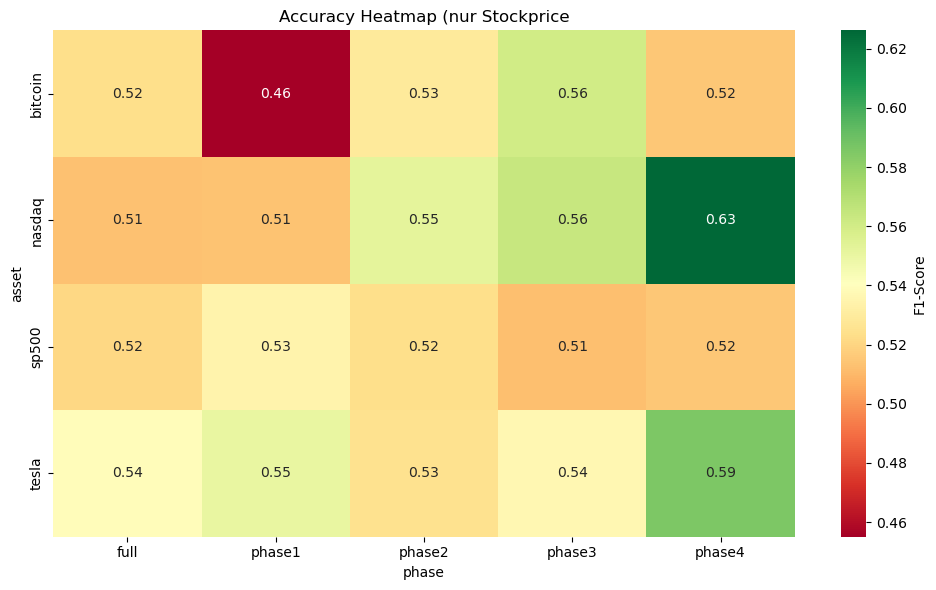

In [108]:
import seaborn as sns

# Pivot-Tabelle für F1-Score
df_stock = df_all[df_all["target"] == "change_stockprice"]

# Pivot-Tabelle für F1-Score (nur Stockprice)
f1_pivot_stock = df_stock.pivot_table(index="asset", columns="phase", values="f1_score", aggfunc="mean")

# Heatmap mit Ampel-Design
plt.figure(figsize=(10, 6))
sns.heatmap(f1_pivot_stock, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'F1-Score'}, vmin=0, vmax=1)
plt.title("F1-Score Heatmap (nur Stockprice)")
plt.tight_layout()
plt.show()

# Pivot-Tabelle für Accuracy
accuracy_pivot_stock = df_all.pivot_table(index="asset", columns="phase", values="accuracy", aggfunc="mean")

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(accuracy_pivot_stock, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'F1-Score'})
plt.title("Accuracy Heatmap (nur Stockprice")
plt.tight_layout()
plt.show()

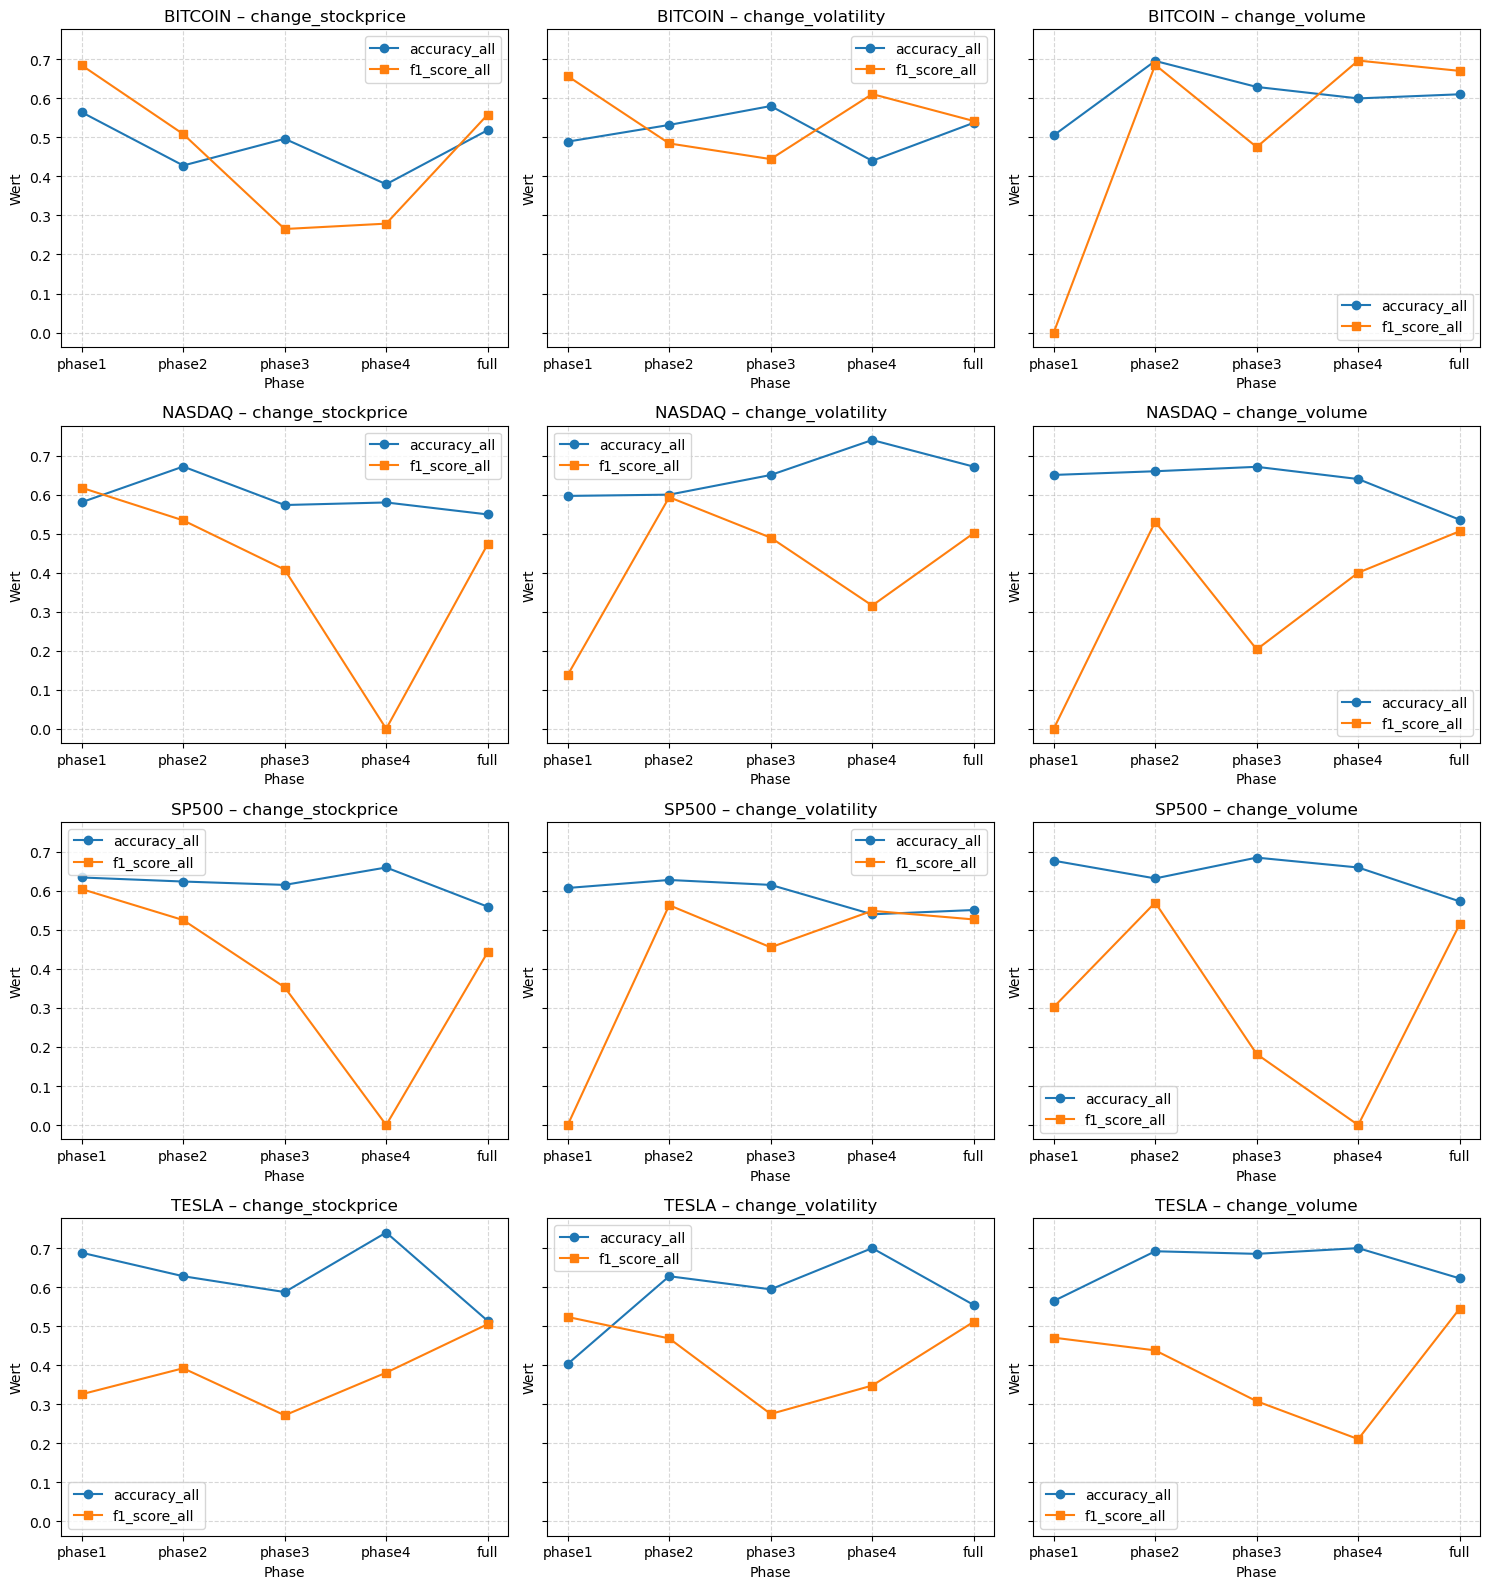

In [102]:
# Gruppieren nach Szenario
grouped = df_merged.groupby(['asset', 'target'])
scenarios = list(grouped.groups.keys())
n_plots = len(scenarios)

# Subplot-Raster: 3 Spalten, so viele Reihen wie nötig
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharey=True)
axes = axes.flatten()

for ax, (asset, target) in zip(axes, scenarios):
    grp = grouped.get_group((asset, target)).sort_values('phase')
    
    # Plot accuracy_all und f1_score_all
    ax.plot(grp['phase'], grp['accuracy_all'], marker='o', label='accuracy_all')
    ax.plot(grp['phase'], grp['f1_score_all'], marker='s', label='f1_score_all')
    
    # Titel, Achsen, Legend
    ax.set_title(f'{asset.upper()} – {target}')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Wert')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')
    
# Leere Subplots entfernen
for ax in axes[n_plots:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Load feature importance csvs

In [103]:
import pandas as pd
from pathlib import Path

# 1) Liste der Features, die wir behalten wollen
keep_features = {
    # 🟦 Tweet Counts & Engagement
    "counts__tweet_count","counts__nlp_tweet_count",
    "counts__likeCount","counts__quoteCount","counts__retweetCount","counts__replyCount",
    # 🟨 Keywords
    "counts__tesla","counts__stock","counts__market","counts__price",
    "counts__profit","counts__loss","counts__revenue","counts__inflation","counts__interest",
    "counts__bitcoin","counts__dogecoin","counts__crypto","counts__ethereum",
    "counts__spacex","counts__model","counts__cybertruck","counts__starship",
    "counts__buy","counts__sell",
    # 🔵 VADER
    "scores__neg","scores__neu","scores__pos","scores__polarized",
    # 🟣 NRC
    "scores__anger","scores__disgust","scores__fear","scores__joy",
    "scores__neutral","scores__sadness","scores__surprise",
    # 🟤 OCEAN
    "scores__Extroversion","scores__Neuroticism","scores__Agreeableness",
    "scores__Conscientiousness","scores__Openness",
    # 🟠 Topics
    "scores__arts_culture","scores__business_entrepreneurs","scores__celebrity_pop_culture",
    "scores__diaries_daily_life","scores__family","scores__fashion_style","scores__film_tv_video",
    "scores__fitness_&_health","scores__food_&_dining","scores__gaming",
    "scores__learning_educational","scores__music","scores__news_social_concern",
    "scores__other_hobbies","scores__relationships","scores__science_technology",
    "scores__sports","scores__travel_adventure","scores__youth_student_life",
    # ⚫ Flags
    "binary__no_tweets"
}

# 2) Alle CSV-Dateien im Verzeichnis feature_importance finden
base = Path("results_all_combinations_final")
paths = list(base.glob("feature_importance_*.csv"))

records = []
for p in paths:
    # parse dateiname: feature_importance_<asset>_change_<metric>_<phase>.csv
    name, _ = p.name.split(".csv")
    _, _, asset, _, metric, phase = name.split("_")
    
    # einlesen
    df = pd.read_csv(p, usecols=["feature","importance"])
    
    # nur die gewünschten Features
    df = df[df["feature"].isin(keep_features)].copy()
    if df.empty:
        # falls in dieser Datei keines der Features vorkommt, überspringen
        continue
    
    # Kontext-Spalten hinzufügen
    df["asset"]   = asset
    df["metric"]  = metric
    df["phase"]   = phase
    
    records.append(df)

# 3) alles zu einem DataFrame zusammenfügen
fi_all_filtered = pd.concat(records, ignore_index=True)

# 4) Spaltenreihenfolge optional anpassen
cols = ["asset","metric","phase","feature","importance"]
fi_all_filtered = fi_all_filtered[cols]

print(f"Zusammengeführtes DataFrame hat {fi_all_filtered.shape[0]} Zeilen und folgende Spalten:")
print(fi_all_filtered.columns.tolist())

print(fi_all_filtered)


ValueError: No objects to concatenate

### Show Top 10 twitter features of every sceanrio

In [ ]:
# Szenario-Definitionen in gewünschter Reihenfolge
assets = ['bitcoin', 'nasdaq', 'sp500', 'tesla']
metrics = sorted(fi_all_filtered['metric'].unique())
phases = ['phase1', 'phase2', 'phase3', 'full']

# Gruppierung vorbereiten
grouped = fi_all_filtered.groupby(['asset', 'metric', 'phase'])

# Raster: eine Spalte je Asset, eine Zeile je (Metric, Phase)
n_rows = len(metrics) * len(phases)
n_cols = len(assets)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*1.8), sharex=False)

for col, asset in enumerate(assets):
    for i, metric in enumerate(metrics):
        for j, phase in enumerate(phases):
            row = i * len(phases) + j
            ax = axes[row][col]
            key = (asset, metric, phase)
            if key in grouped.groups:
                sub = grouped.get_group(key)
                top10 = sub.nlargest(10, 'importance')
                ax.barh(top10['feature'], top10['importance'])
                ax.invert_yaxis()
                ax.grid(True, axis='x', linestyle='--', alpha=0.5)

                # Nur in der ersten Spalte Beschriftung der Zeilen
                if col == 0:
                    ax.set_ylabel(f'{metric} – {phase}')
                # Nur in der oberen Reihe Titelnamen für Asset
                if row == 0:
                    ax.set_title(asset.upper())
            else:
                ax.axis('off')

plt.tight_layout()
plt.show()